### Modelos entrenados para predecir la Potabilidad del AGUA

Se van a probar estos dos modelos para analizar cual aporta mas para predecir la potabilidad del Agua:

#### 1-Logistic Regression

Es un modelo lineal base.
Prrmite interpretar coeficientes.

Funciona bien cuando la separación es aproximadamente lineal.

Sirve como baseline sólido.

#### 2-XGBoost

Modelo de boosting basado en árboles.

Maneja relaciones no lineales.

Es uno de los mejores modelos para datos tabulares.

Suele mejorar recall y AUC en problemas desbalanceados.

#### Comparar ambos permite evaluar:

Si el problema es casi lineal (LR funciona bien)

O si requiere modelamiento no lineal (XGBoost mejora resultados)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

In [4]:
ruta = 'C:/Users/Sandra/Documents/UNIANDES_Maestria_AI/SEMESTRE_4/2-Proyecto - Desarrollo de Soluciones/Proyecto_Potabilidad_ModeloSMPC/data/Datos_Etapa-2.csv'
data_raw = pd.read_csv(ruta, sep=',', na_values=['?'], encoding = 'utf-8')

In [5]:
#Veamos los primeros datos del conjunto utilizando head():
data_raw.head()

,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez,Potabilidad
0,NaN,204.89,20791.32,7.30,368.52,564.31,10.38,86.99,2.96,NO
1,3.72,129.42,18630.06,6.64,NaN,592.89,15.18,56.33,4.50,NO
2,8.10,224.24,19909.54,9.28,NaN,418.61,16.87,66.42,3.06,NO
3,8.32,214.37,22018.42,8.06,356.89,363.27,18.44,100.34,4.63,NO
4,9.09,181.10,17978.99,6.55,310.14,398.41,11.56,32.00,4.08,NO


1- Exploración y perfilamiento de los datos

Primero utilizaremos data_raw.describe() para obtener una descripción de las variables numéricas del conjunto de datos.

In [7]:
data_raw.describe()

,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000
mean,7.080804,196.369481,22014.092415,7.122241,333.775784,426.205171,14.284921,66.396281,3.966731
std,1.594369,32.879680,8768.570852,1.583143,41.416864,80.824123,3.308232,16.174983,0.780354
min,0.000000,47.430000,320.940000,0.350000,129.000000,181.480000,2.200000,0.740000,1.450000
25%,6.090000,176.847500,15666.687500,6.130000,307.695000,365.735000,12.070000,55.847500,3.440000
50%,7.040000,196.965000,20927.830000,7.130000,333.070000,421.885000,14.220000,66.620000,3.955000
75%,8.060000,216.670000,27332.760000,8.112500,359.950000,481.790000,16.560000,77.337500,4.500000
max,14.000000,323.120000,61227.200000,13.130000,481.030000,753.340000,28.300000,124.000000,6.740000


Utilizo value_counts para obtener cada valor posible de la variable categórica y su frecuencia de aparición sobre el total de los datos. En este caso, obtenemos la distribución de valores para la variable Potabilidad:

In [9]:
data_raw.Potabilidad.value_counts()

Potabilidad
NO    1998
SI    1278
Name: count, dtype: int64

2-Limpieza y preparación de los datos

Primero vamos a definir la variable data para almacenar un conjunto de datos modificado, utilizando el método copy():

In [11]:
#Primero vamos a definir la variable data para almacenar un conjunto de datos modificado:
data = data_raw.copy()

In [12]:
#Veremos si hay duplicados utilizando duplicated().sum():
data.duplicated().sum()

0

In [13]:
data.shape

(3276, 10)

#### Transformación de variables categóricas
 la implementación de sklearn necesita que todos los valores de las variables sean numéricos, por lo que realizaremos una codificació LabelEncoder, para nuestra variable categórica objetivo Potabilidad que manejar 1s y 0s para SI y NO respectivamente.n

In [15]:
label_encoder = LabelEncoder()
data['Potabilidad'] = label_encoder.fit_transform(data['Potabilidad'])

In [16]:
data.head()

,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez,Potabilidad
0,NaN,204.89,20791.32,7.30,368.52,564.31,10.38,86.99,2.96,0
1,3.72,129.42,18630.06,6.64,NaN,592.89,15.18,56.33,4.50,0
2,8.10,224.24,19909.54,9.28,NaN,418.61,16.87,66.42,3.06,0
3,8.32,214.37,22018.42,8.06,356.89,363.27,18.44,100.34,4.63,0
4,9.09,181.10,17978.99,6.55,310.14,398.41,11.56,32.00,4.08,0


In [17]:
data.shape

(3276, 10)

#### Tratamiento de nulos

In [19]:
#Revisaremos si nuestros datos contienen datos nulos
data.isna().sum()

pH                  491
Dureza                0
Sólidos               0
Cloraminas            0
Sulfatos            781
Conductividad         0
Carbono_orgánico      0
Trihalometanos      162
Turbidez              0
Potabilidad           0
dtype: int64

En vez de eliminar estos datos, realizaremos una imputación para reemplazar los valores nulos por valores como la media, mediana, entre otros. En ese sentido, definiremos dos objetos de la clase SimpleImputer(), especificando que reemplazaremos los valores nulos por el valor más frecuente (para las variables categóricas) y por la media (para las variables numéricas):

In [21]:
#cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer = SimpleImputer(strategy='mean')

Haremos este proceso en un paso del pipeline mediante un objeto de la clase ColumnTransformer(), especificando el arreglo con los índices de las variables numéricas y categóricas. Nos damos cuenta que las variables de entrada solo son numericas entonces le hacemos imputación solo al conjunto de variables numericas:

In [23]:
# Variables ph, Dureza, Solidos, Cloraminas, Sulfatos, Conductividad, Carbono_organico, Trihalomnetanos, Turbidez, 
numeric_features = [0, 1, 2, 3, 4, 5, 6, 7, 8]
#categorical_features = [9]
# Variable categorical Potabilidad no se tienen en cuenta por q es variable objetivo!! ademas tampoco es nula.

imputer = ColumnTransformer(
    transformers=[
        ("num", num_imputer, numeric_features),
#        ("cat", cat_imputer, categorical_features)
    ]
)

#### Análisis exploratorio de los datos luego de limpieza y trasformaciones

In [25]:
data.describe()


,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez,Potabilidad
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080804,196.369481,22014.092415,7.122241,333.775784,426.205171,14.284921,66.396281,3.966731,0.390110
std,1.594369,32.879680,8768.570852,1.583143,41.416864,80.824123,3.308232,16.174983,0.780354,0.487849
min,0.000000,47.430000,320.940000,0.350000,129.000000,181.480000,2.200000,0.740000,1.450000,0.000000
25%,6.090000,176.847500,15666.687500,6.130000,307.695000,365.735000,12.070000,55.847500,3.440000,0.000000
50%,7.040000,196.965000,20927.830000,7.130000,333.070000,421.885000,14.220000,66.620000,3.955000,0.000000
75%,8.060000,216.670000,27332.760000,8.112500,359.950000,481.790000,16.560000,77.337500,4.500000,1.000000
max,14.000000,323.120000,61227.200000,13.130000,481.030000,753.340000,28.300000,124.000000,6.740000,1.000000


In [26]:
data["Potabilidad"].value_counts(normalize=True)

Potabilidad
0    0.60989
1    0.39011
Name: proportion, dtype: float64

#### Analisis de outliers

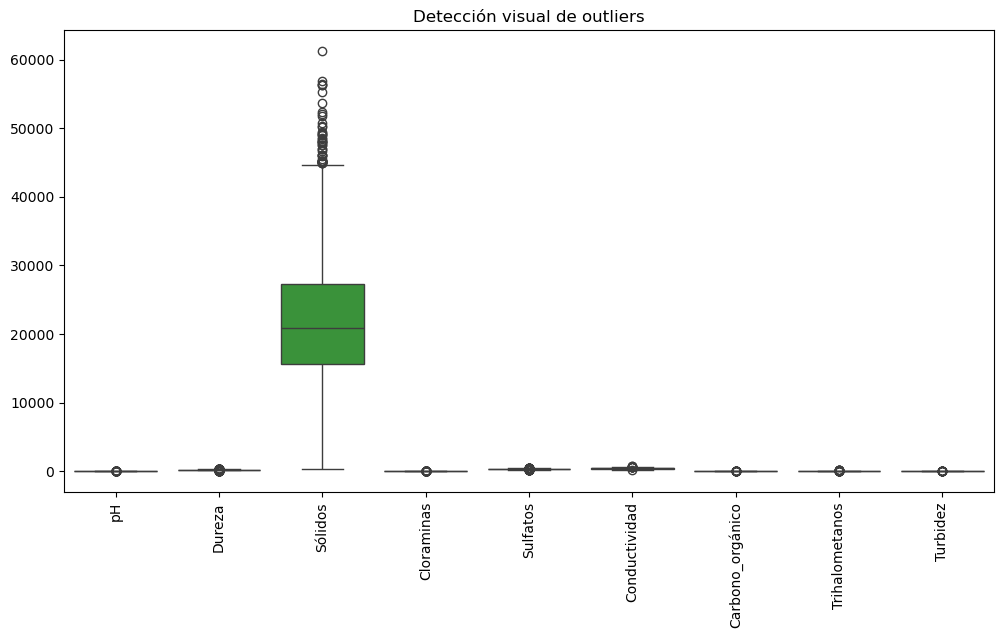

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=data.drop("Potabilidad", axis=1))
plt.xticks(rotation=90)
plt.title("Detección visual de outliers")
plt.show()

#### Asegurar variable objetivo y definir X/y

In [30]:
# Asegurar que Potabilidad sea 0/1 entero (si ya viene numérica, esto solo normaliza)
data["Potabilidad"] = pd.to_numeric(data["Potabilidad"], errors="coerce").astype("Int64")

# (Opcional) si por alguna razón viniera como "SI/NO", descomenta:
# data["Potabilidad"] = data["Potabilidad"].map({"NO":0, "SI":1}).astype("Int64")

print("Nulos por columna:\n", data.isna().sum())
print("\nDistribución de clases (Potabilidad):\n", data["Potabilidad"].value_counts(dropna=False))

X = data.drop(columns=["Potabilidad"])
y = data["Potabilidad"].astype(int)   # ya sin nulos en y

Nulos por columna:
 pH                  491
Dureza                0
Sólidos               0
Cloraminas            0
Sulfatos            781
Conductividad         0
Carbono_orgánico      0
Trihalometanos      162
Turbidez              0
Potabilidad           0
dtype: int64

Distribución de clases (Potabilidad):
 Potabilidad
0    1998
1    1278
Name: count, dtype: Int64


#### División de datos - Split (con stratify)

Ahora dividiremos el conjunto de datos resultante en un conjunto de entrenamiento y uno de pruebas mediante la función train_test_split(). Usaremos el 80% de los datos para el entrenamiento y el 20% restante para las pruebas:

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (2620, 9) Test: (656, 9)


### Pipelines de los 2 modelos (LogReg y XGBoost)

#### Logistic Regression (necesita escalado)

In [35]:
lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

#### XGBoost (no requiere escalado) + ajuste por desbalance

In [37]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

xgb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ))
])

#### Evaluación (accuracy, precision, recall, F1 y AUC)


📌 Logistic Regression
Accuracy : 0.524
Precision: 0.415
Recall   : 0.531
F1-score : 0.466
AUC      : 0.548


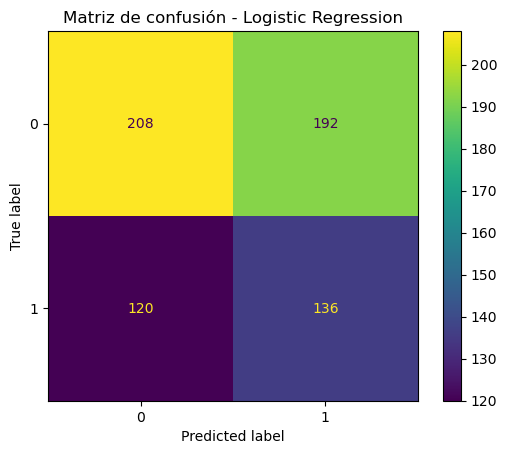


📌 XGBoost
Accuracy : 0.630
Precision: 0.527
Recall   : 0.492
F1-score : 0.509
AUC      : 0.654


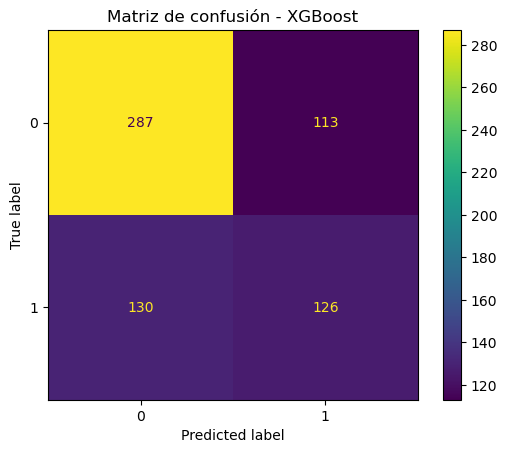

In [39]:
def evaluar_modelo(nombre, modelo):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n📌 {nombre}")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-score : {f1:.3f}")
    print(f"AUC      : {auc:.3f}")

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

    return {"Model": nombre, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC": auc, "y_prob": y_prob}

res_lr = evaluar_modelo("Logistic Regression", lr_pipeline)
res_xgb = evaluar_modelo("XGBoost", xgb_pipeline)

#### Curva ROC comparativa

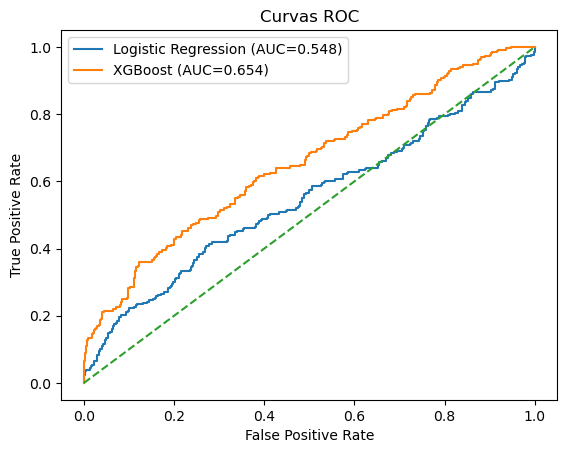

In [44]:
plt.figure()
for r in [res_lr, res_xgb]:
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    plt.plot(fpr, tpr, label=f'{r["Model"]} (AUC={r["AUC"]:.3f})')

plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC")
plt.legend()
plt.show()

#### Tabla final

In [46]:
results = pd.DataFrame([res_lr, res_xgb])[["Model","Accuracy","Precision","Recall","F1","AUC"]]
results

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.524390,0.414634,0.531250,0.465753,0.547539
1,XGBoost,0.629573,0.527197,0.492188,0.509091,0.653857


In [78]:
tabla_interpretacion = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score", "AUC"],
    "Modelo con Mejor Resultado": [
        "XGBoost",
        "XGBoost",
        "Logistic Regression",
        "XGBoost",
        "XGBoost"
    ],
    "Interpretación": [
        "Mejor desempeño global.",
        "Reduce falsos positivos (más seguro sanitariamente).",
        "Detecta ligeramente más casos potables reales.",
        "Mejor equilibrio entre precision y recall.",
        "Mejor capacidad de discriminación entre clases."
    ]
})

tabla_interpretacion

,Métrica,Modelo con Mejor Resultado,Interpretación
0,Accuracy,XGBoost,Mejor desempeño global.
1,Precision,XGBoost,Reduce falsos positivos (más seguro sanitariam...
2,Recall,Logistic Regression,Detecta ligeramente más casos potables reales.
3,F1-score,XGBoost,Mejor equilibrio entre precision y recall.
4,AUC,XGBoost,Mejor capacidad de discriminación entre clases.


### Análisis y conclusiones:

XGBoost supera a Logistic Regression en 4 de 5 métricas.

La única métrica donde LR es ligeramente superior es Recall.

Sin embargo, XGBoost mejora Precision y AUC, reduciendo riesgo sanitario.

Por lo tanto, XGBoost es el modelo recomendado.


### Conclusiones

Se evaluaron dos modelos supervisados para predecir la potabilidad del agua: Logistic Regression y XGBoost.

XGBoost presentó un mejor desempeño global, evidenciado en mayores valores de Accuracy (0.63), F1-score (0.509) y AUC (0.654), lo que indica una mejor capacidad de discriminación entre agua potable y no potable.

Aunque Logistic Regression mostró un Recall ligeramente superior para la clase potable (0.531), su baja Precision (0.415) implica una mayor tasa de falsos positivos, es decir, clasificar agua no potable como potable, lo cual representa un riesgo sanitario significativo.

En contraste, XGBoost mejora la precisión en la detección de agua potable (0.527), reduciendo el riesgo de clasificación errónea de agua no segura como potable. Esto lo convierte en el modelo más adecuado para el problema, especialmente bajo criterios de seguridad y control sanitario.

Además, el análisis de importancia de variables sugiere que atributos como pH, Cloraminas, Sulfatos y Dureza tienen mayor influencia en la determinación de la potabilidad, lo que confirma que la relación entre variables fisicoquímicas y potabilidad no es estrictamente lineal.